# Reconstruction

One of the tasks we aim to solve is to learn a basis function that is well suited for reconstructing functions from a given dataset that have a specific unknown distribution. We will make the simplifying assumption that the underlying function is a linear combination of at most $L$ bases functions; this is a reasonable assumption in both partial differential equations and signal processing that allows us to better approximate and study functions of interest. Thus, we will assume that the functions form a linear subspace $\mathcal{F} \subseteq L^2(\Omega)$ of dimension $L$.

In [1]:
%load_ext autoreload
import torch
import numpy as np
import matplotlib.pyplot as plt
import math
import sys

sys.path.append('..')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In this notebook, we incarnate an example of such a dataset by considering bases constructed from trigonometric functions. 

For any given set of values $\{r_i^{\sin}, \omega_{i,0}^{\sin}, \omega_{i, 1}^{\sin}, \phi_i^{\sin}\}_{i=1}^{L^{\sin}}$ and $\{r_i^{\cos}, \omega_{i,0}^{\cos}, \omega_{i, 1}^{\cos}, \phi_i^{\cos}\}_{i=1}^{L^{\cos}}$, the following basis functions are constructed:
$$e^{\sin}_i(x, y) = r_i^{\sin} \sin(\omega_{i, 0}^{\sin} x + \omega_{i, 1}^{\sin} y + \phi_i^{\sin}), \qquad e^{\cos}_i(x, y) = r_i^{\cos} \cos(\omega_{i, 0}^{\cos} x + \omega_{i, 1}^{\cos} y + \phi_i^{\cos})$$
And then, any function $f(x, y)$ is obtained via linear combinations of these basis functions:
$$f(x, y) = \sum_{i=1}^{L^{\sin}} W^{\sin}_i e_i^{\sin}(x, y) + \sum_{i=1}^{L^{\cos}} W_i^{\cos} e_i^{\cos}(x, y)$$

The frequencies $\omega_{i, j}^{\sin}, \omega_{i, j}^{\cos}$ are sampled from a bandpass uniform distribution defined by $\omega_{lo}, \omega_{hi}$, the amplitudes $r_i^{\sin}$ and $r_i^{\cos}$ are sampled from a uniform distribution $r_{lo}$ and $r_{hi}$, and finally, the phases are also sampled uniformly in $[0, 2\pi)$.

The following piece of code instantiates such a dataset and visualizes its heatmaps:

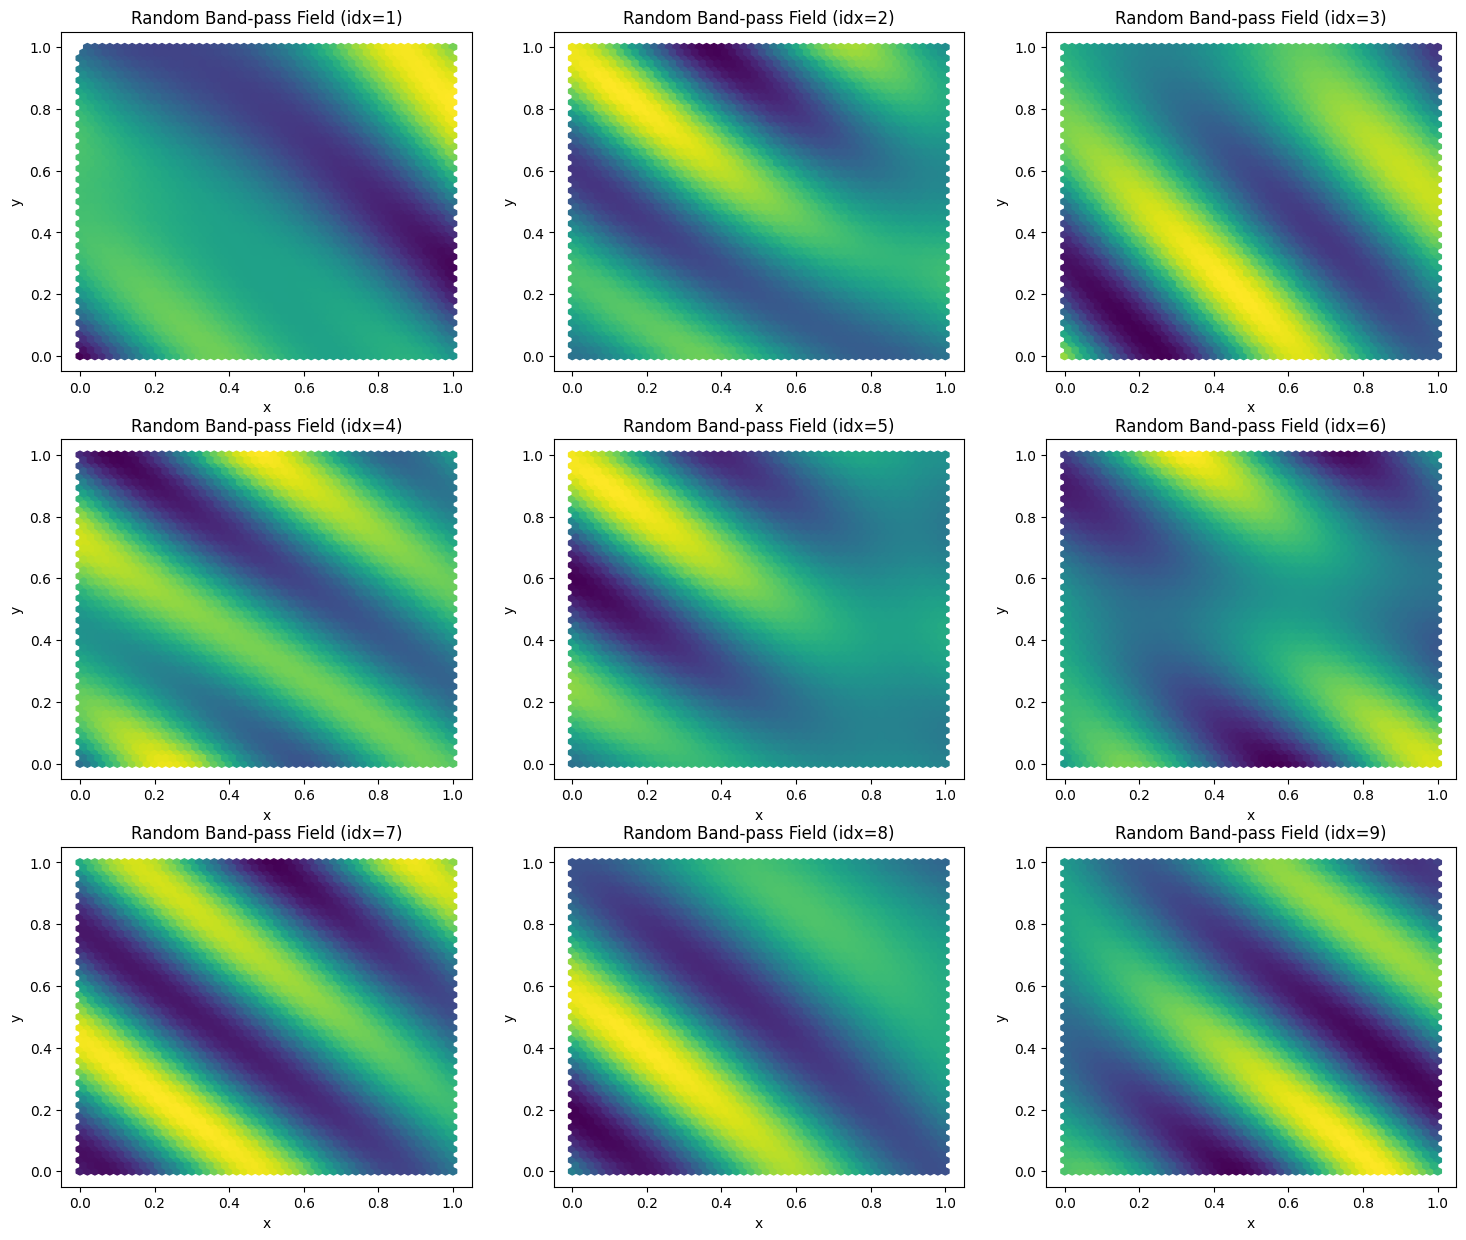

In [2]:
%autoreload 2
from basis_learning.datasets import random_bandpass

# Example
fig, axes = plt.subplots(figsize=(6 * 3,5 * 3), nrows=3, ncols=3)
N = 5000_0
dset_kwargs = dict( 
    omega_lo=5,
    omega_hi=10,
    r_lo=0.5,
    r_hi=1.0,
    l_sin=5,
    l_cos=5,
    dset_seed=1024,
)
idx = 0
for row_idx, f_range in enumerate([(1.0, 10.0), (10.0, 20.0), (50.0, 60.0)]):
    f_lo, f_hi = f_range
    for col_idx, seed in enumerate([42, 43, 44]):
        ax = axes[row_idx, col_idx]
        xy = torch.rand(N, 2).to(device)
        field = random_bandpass(
            xy, 
            datum_idx=idx,
            **dset_kwargs,
        )  # shape (N,)
        idx += 1
        ax.hexbin(xy.detach().cpu()[:,0], xy.detach().cpu()[:,1], C=field.detach().cpu(), gridsize=50, cmap='viridis') 
        ax.set_title(f'Random Band-pass Field (idx={idx})')
        ax.set_xlabel('x')
        ax.set_ylabel('y')
plt.show()